1. Basic Structural Overview

In [1]:
import pandas as pd

In [2]:
# Load the Dataset
DRclassification_df = pd.read_csv("Deep Learning csv/data.csv", encoding='utf-8')

In [3]:
# View the first 5 rows
print(DRclassification_df.head())

   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   3           66        Male  3_left.jpg  3_right.jpg   
4   4           53        Male  4_left.jpg  4_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                                      normal fundus   
4                        macular epiretinal membrane   

                Right-Diagnostic Keywords  N  D  G  C  A  H  M  O  
0                           normal fundus  0  0  0  1  0  0  0  0  
1                           normal fundus  1  0  0  0  0  0  0  0  
2  moderate non proliferative retinopathy  0  1  0  0  0  0  0  1  
3         branch retinal artery occl

In [4]:
# View the data types and check for missing values
print(DRclassification_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   ID                         3500 non-null   int64
 1   Patient Age                3500 non-null   int64
 2   Patient Sex                3500 non-null   str  
 3   Left-Fundus                3500 non-null   str  
 4   Right-Fundus               3500 non-null   str  
 5   Left-Diagnostic Keywords   3500 non-null   str  
 6   Right-Diagnostic Keywords  3500 non-null   str  
 7   N                          3500 non-null   int64
 8   D                          3500 non-null   int64
 9   G                          3500 non-null   int64
 10  C                          3500 non-null   int64
 11  A                          3500 non-null   int64
 12  H                          3500 non-null   int64
 13  M                          3500 non-null   int64
 14  O                          3500 non

In [5]:
# View basic statistics (Min, Max, Mean) of numerical columns
print(DRclassification_df.describe())

                ID  Patient Age            N            D            G  \
count  3500.000000  3500.000000  3500.000000  3500.000000  3500.000000   
mean   2218.233143    57.854000     0.325714     0.322286     0.061429   
std    1415.437872    11.724064     0.468708     0.467419     0.240149   
min       0.000000     1.000000     0.000000     0.000000     0.000000   
25%     876.750000    51.000000     0.000000     0.000000     0.000000   
50%    2372.500000    59.000000     0.000000     0.000000     0.000000   
75%    3247.250000    66.000000     1.000000     1.000000     0.000000   
max    4784.000000    91.000000     1.000000     1.000000     1.000000   

                 C            A            H            M            O  
count  3500.000000  3500.000000  3500.000000  3500.000000  3500.000000  
mean      0.060571     0.046857     0.029429     0.049714     0.279714  
std       0.238577     0.211363     0.169029     0.217385     0.448923  
min       0.000000     0.000000     0.000

2. Data Integrity Check

In [6]:
# --- Check for Missing Values ---
print("Missing values per column:")
print(DRclassification_df.isnull().sum())

Missing values per column:
ID                           0
Patient Age                  0
Patient Sex                  0
Left-Fundus                  0
Right-Fundus                 0
Left-Diagnostic Keywords     0
Right-Diagnostic Keywords    0
N                            0
D                            0
G                            0
C                            0
A                            0
H                            0
M                            0
O                            0
dtype: int64


3. Demographic Analysis

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

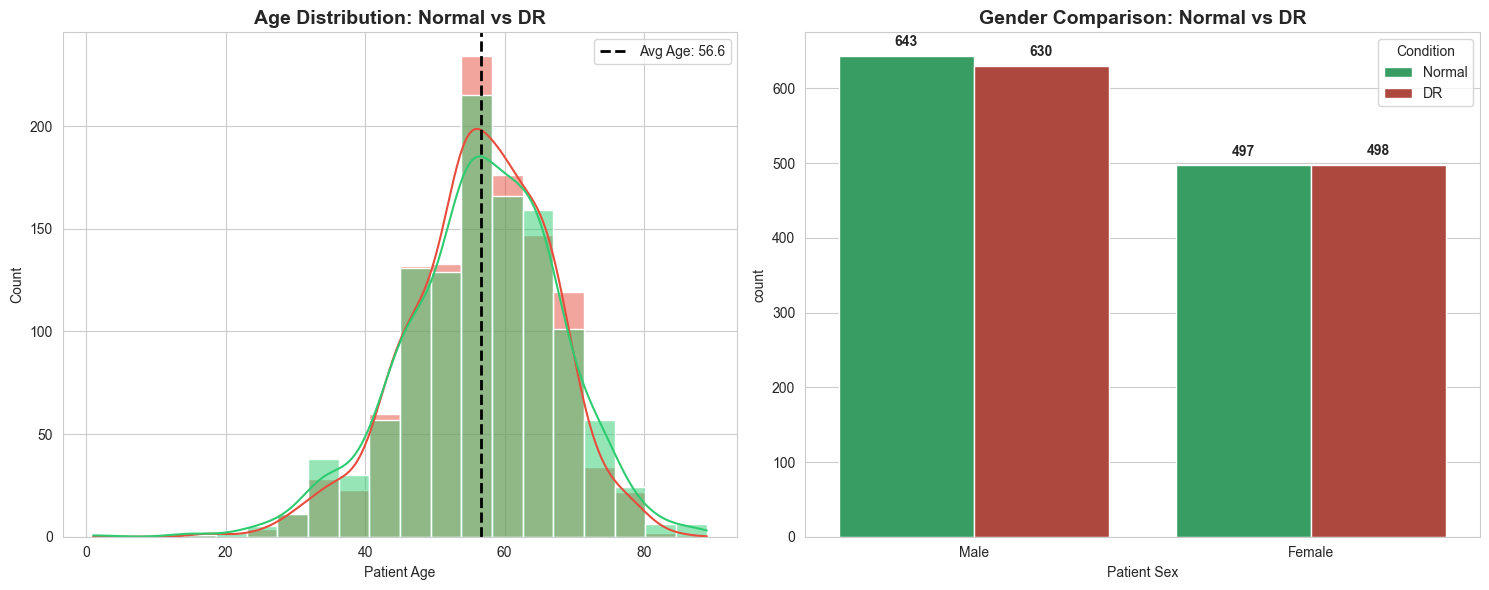

In [8]:
# --- STEP 1: Create a safe copy for visualization ---
# This prevents the "changing numbers" bug by leaving the original 3500 rows untouched
df_plot = DRclassification_df.copy()

def map_odir_labels(row):
    if row['D'] == 1:
        return 'DR'
    elif row['N'] == 1:
        return 'Normal'
    return 'Other'

df_plot['Condition'] = df_plot.apply(map_odir_labels, axis=1)

# Filter the COPY, not the original
df_plot = df_plot[df_plot['Condition'] != 'Other']

# --- STEP 2: SETUP THE ENHANCED VISUALS ---
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Enhancement: Calculate stats specifically for the filtered group
mean_age = df_plot['Patient Age'].mean()

# --- PLOT 1: AGE DISTRIBUTION (Normal vs DR) ---
sns.histplot(
    data=df_plot, 
    x='Patient Age', 
    hue='Condition', 
    kde=True, 
    bins=20, 
    palette={'Normal': '#2ecc71', 'DR': '#e74c3c'}, # Green for Normal, Red for DR
    edgecolor='white', 
    ax=axes[0]
)

# Add Vertical Line for Mean
axes[0].axvline(mean_age, color='black', linestyle='--', linewidth=2, label=f'Avg Age: {mean_age:.1f}')
axes[0].set_title('Age Distribution: Normal vs DR', fontsize=14, fontweight='bold')
axes[0].legend()

# --- PLOT 2: GENDER DISTRIBUTION (Stacked/Grouped) ---
sns.countplot(
    data=df_plot, 
    x='Patient Sex', 
    hue='Condition', 
    palette={'Normal': '#27ae60', 'DR': '#c0392b'},
    ax=axes[1]
)
axes[1].set_title('Gender Comparison: Normal vs DR', fontsize=14, fontweight='bold')

# Enhancement: Add count labels on top of bars
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(f'{int(p.get_height())}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 10), 
                        textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

4. Target Class Counts

In [9]:
# 1. Define the labels
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
total_rows = len(DRclassification_df)

print(f"{'Label':<6} | {'Present (1)':<12} | {'Absent (0)':<12}")
print("-" * 35)

for col in label_cols:
    ones = DRclassification_df[col].sum()
    zeros = total_rows - ones
    print(f"{col:<6} | {ones:<12} | {zeros:<12}")

print(f"\nTotal Records: {total_rows}")

Label  | Present (1)  | Absent (0)  
-----------------------------------
N      | 1140         | 2360        
D      | 1128         | 2372        
G      | 215          | 3285        
C      | 212          | 3288        
A      | 164          | 3336        
H      | 103          | 3397        
M      | 174          | 3326        
O      | 979          | 2521        

Total Records: 3500


In [10]:
print("\n--- FINAL CLASS COUNTS ---")

# 1. Count occurrences of Normal (N) cases
normal_count = DRclassification_df['N'].sum()
print(f"Normal Cases (N): {normal_count}")

# 2. Count occurrences of Diabetes/DR (D) cases
dr_count = DRclassification_df['D'].sum()
print(f"Diabetes Cases (D): {dr_count}")

# 3. Calculate "Others" category
other_cols = ['G', 'C', 'A', 'H', 'M', 'O']

existing_others = [col for col in other_cols if col in DRclassification_df.columns]

if existing_others:
    others_count = DRclassification_df[existing_others].sum().sum()
else:
    others_count = DRclassification_df['Other_Disease'].sum()

print(f"Other Conditions:   {others_count}")



--- FINAL CLASS COUNTS ---
Normal Cases (N): 1140
Diabetes Cases (D): 1128
Other Conditions:   1847


In [11]:
# --- STEP 1: Create the Binary Subset ---
# We use .copy() to prevent the "changing numbers" bug in your notebook
df_binary = DRclassification_df[(DRclassification_df['N'] == 1) | (DRclassification_df['D'] == 1)].copy()

# Map labels for the graphs
df_binary['Condition'] = df_binary['D'].map({0: 'Normal', 1: 'DR'})

# --- STEP 2: PRINT THE FINAL CLASS COUNTS ---
print("--- FINAL CLASS COUNTS ---")
normal_count = (df_binary['N'] == 1).sum()
dr_count = (df_binary['D'] == 1).sum()

print(f"Normal Cases (N): {normal_count}")
print(f"Diabetes Cases (D): {dr_count}")
print(f"Total Binary Samples: {len(df_binary)}")

--- FINAL CLASS COUNTS ---
Normal Cases (N): 1140
Diabetes Cases (D): 1128
Total Binary Samples: 2268


In [12]:
# 1. Filter the dataset to only include Diabetic patients
dr_patients = DRclassification_df[DRclassification_df['D'] == 1].copy()

# 2. Define the other disease columns
other_diseases = ['G', 'C', 'A', 'H', 'M', 'O']

# 3. Calculate "Only Diabetic" (D=1 and all others are 0)
only_dr_count = len(dr_patients[dr_patients[other_diseases].sum(axis=1) == 0])

# 4. Calculate "Diabetic + Other Disease" (D=1 and at least one other is 1)
dr_and_others_count = len(dr_patients[dr_patients[other_diseases].sum(axis=1) > 0])

print(f"Total Diabetic Patients (D=1): {len(dr_patients)}")
print()
print(f"Only Diabetic (Pure DR): {only_dr_count}")
print(f"Diabetic + Other Diseases: {dr_and_others_count}")

# Optional: Show which other diseases are most common in diabetic patients
print("\nBreakdown of comorbidities in DR patients:")
print(dr_patients[other_diseases].sum().sort_values(ascending=False))

Total Diabetic Patients (D=1): 1128

Only Diabetic (Pure DR): 697
Diabetic + Other Diseases: 431

Breakdown of comorbidities in DR patients:
O    303
H     45
C     39
G     32
M     19
A     16
dtype: int64


5. Data Restructuring (One Row Per Image)

In [13]:
import pandas as pd

In [14]:
# 1. Create a Patient_ID to keep eyes linked
df_binary['Patient_ID'] = df_binary.index

# --- NEW STEP: Create the "Other_Disease" Column ---
# This checks G, C, A, H, M, O and puts a 1 if any are present
other_disease_cols = ['G', 'C', 'A', 'H', 'M', 'O']
df_binary['Other_Disease'] = (df_binary[other_disease_cols].sum(axis=1) > 0).astype(int)

# --- 2. Create the LEFT EYE Dataset ---
left_df = df_binary.copy()
left_df['Image_Path'] = left_df['Left-Fundus']
left_df['Diagnostic_Keywords'] = left_df['Left-Diagnostic Keywords']
left_df['Eye_Side'] = 'Left'
# Remove side-specific columns
left_df = left_df.drop(columns=['Left-Fundus', 'Right-Fundus', 
                                'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords'])

# --- 3. Create the RIGHT EYE Dataset ---
right_df = df_binary.copy()
right_df['Image_Path'] = right_df['Right-Fundus']
right_df['Diagnostic_Keywords'] = right_df['Right-Diagnostic Keywords']
right_df['Eye_Side'] = 'Right'
# Remove side-specific columns
right_df = right_df.drop(columns=['Left-Fundus', 'Right-Fundus', 
                                  'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords'])

# --- 4. Combine and Sort ---
# Stacks the rows and ensures the same patient's eyes are in adjacent rows
DR_Image_Level_df = pd.concat([left_df, right_df], axis=0)
DR_Image_Level_df = DR_Image_Level_df.sort_values(by=['Patient_ID', 'Eye_Side']).reset_index(drop=True)

# --- 5. Clean up column order for display ---
cols = ['Patient_ID', 'Image_Path', 'Eye_Side', 'N', 'D', 'Other_Disease', 'Diagnostic_Keywords', 'Patient Age', 'Patient Sex']
# Add back the individual disease columns at the end
remaining_cols = [c for c in DR_Image_Level_df.columns if c not in cols]
DR_Image_Level_df = DR_Image_Level_df[cols + remaining_cols]

In [15]:
print(DR_Image_Level_df.head())

   Patient_ID   Image_Path Eye_Side  N  D  Other_Disease  \
0           1   1_left.jpg     Left  1  0              0   
1           1  1_right.jpg    Right  1  0              0   
2           2   2_left.jpg     Left  0  1              1   
3           2  2_right.jpg    Right  0  1              1   
4           4   4_left.jpg     Left  0  1              1   

                                 Diagnostic_Keywords  Patient Age Patient Sex  \
0                                      normal fundus           57        Male   
1                                      normal fundus           57        Male   
2  laser spot，moderate non proliferative retinopathy           42        Male   
3             moderate non proliferative retinopathy           42        Male   
4                        macular epiretinal membrane           53        Male   

   ID  G  C  A  H  M  O Condition  
0   1  0  0  0  0  0  0    Normal  
1   1  0  0  0  0  0  0    Normal  
2   2  0  0  0  0  0  1        DR  
3   2  0

In [16]:
print(DR_Image_Level_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4536 entries, 0 to 4535
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Patient_ID           4536 non-null   int64
 1   Image_Path           4536 non-null   str  
 2   Eye_Side             4536 non-null   str  
 3   N                    4536 non-null   int64
 4   D                    4536 non-null   int64
 5   Other_Disease        4536 non-null   int64
 6   Diagnostic_Keywords  4536 non-null   str  
 7   Patient Age          4536 non-null   int64
 8   Patient Sex          4536 non-null   str  
 9   ID                   4536 non-null   int64
 10  G                    4536 non-null   int64
 11  C                    4536 non-null   int64
 12  A                    4536 non-null   int64
 13  H                    4536 non-null   int64
 14  M                    4536 non-null   int64
 15  O                    4536 non-null   int64
 16  Condition            4536 non-null 

In [17]:
print(DR_Image_Level_df.describe())

        Patient_ID            N            D  Other_Disease  Patient Age  \
count  4536.000000  4536.000000  4536.000000    4536.000000  4536.000000   
mean   2190.067901     0.502646     0.497354       0.190035    56.553792   
std     932.121288     0.500048     0.500048       0.392372    10.697658   
min       1.000000     0.000000     0.000000       0.000000     1.000000   
25%    1790.750000     0.000000     0.000000       0.000000    50.000000   
50%    2357.500000     1.000000     0.000000       0.000000    57.000000   
75%    2924.250000     1.000000     1.000000       0.000000    64.000000   
max    3498.000000     1.000000     1.000000       1.000000    89.000000   

                ID            G            C            A            H  \
count  4536.000000  4536.000000  4536.000000  4536.000000  4536.000000   
mean   2844.534392     0.014109     0.017196     0.007055     0.019841   
std    1306.944309     0.117955     0.130015     0.083705     0.139470   
min       1.000000 

In [18]:
# Identify the 52 problematic rows
problem_rows = DR_Image_Level_df[(DR_Image_Level_df['N'] == 1) & (DR_Image_Level_df['Other_Disease'] == 1)]

print(f"Investigating {len(problem_rows)} 'Normal + Other' cases...")
# Display the Patient_ID and the clean Keywords
display(problem_rows[['Patient_ID', 'Diagnostic_Keywords', 'Other_Disease']].head(10))

Investigating 0 'Normal + Other' cases...


,Patient_ID,Diagnostic_Keywords,Other_Disease


6. Diagnostic Keyword Analysis

In [19]:
# Standardize text: Fix Chinese commas, merge multiple spaces, and trim edges
DR_Image_Level_df['Diagnostic_Keywords'] = (
    DR_Image_Level_df['Diagnostic_Keywords']
    .str.replace('，', ',', regex=False)   # Replace Chinese comma
    .str.replace(r'\s+', ' ', regex=True) # Collapse multiple spaces into one
    .str.strip()                          # Remove leading/trailing spaces
)


In [20]:
import pandas as pd
from collections import Counter

# 1. Extract all phrases into a single list
all_phrases = []

for keywords in DR_Image_Level_df['Diagnostic_Keywords'].dropna():
    # Split by both standard and Chinese commas
    parts = str(keywords).replace('，', ',').split(',')
    # Clean up whitespace and lowercase for consistency
    all_phrases.extend([p.strip().lower() for p in parts if p.strip()])

# 2. Count occurrences
phrase_counts = Counter(all_phrases)

# 3. Create a clean Summary Table
keyword_summary = pd.DataFrame(phrase_counts.items(), columns=['Clinical_Keyword', 'Frequency'])
keyword_summary = keyword_summary.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

# 4. Display the results
print(f"Total Unique Clinical Phrases Found: {len(keyword_summary)}")
print("-" * 50)
print(keyword_summary.to_string())

Total Unique Clinical Phrases Found: 62
--------------------------------------------------
                                         Clinical_Keyword  Frequency
0                                           normal fundus       2534
1                  moderate non proliferative retinopathy        997
2                       mild nonproliferative retinopathy        552
3                                               lens dust        270
4                     severe nonproliferative retinopathy        161
5                                hypertensive retinopathy         85
6                                              laser spot         81
7                             macular epiretinal membrane         67
8                                     epiretinal membrane         65
9                                    diabetic retinopathy         56
10                                               cataract         47
11                                                 drusen         34
12          

In [21]:
import pandas as pd

def clean_and_grade_dataset(df):
    # 1. Standardize text immediately
    df['Diagnostic_Keywords'] = df['Diagnostic_Keywords'].str.replace('，', ',').str.lower()
    
    clean_rows = []
    
    for index, row in df.iterrows():
        keywords = row['Diagnostic_Keywords']
        
        # --- RULE 1: LOGIC FOR DR GRADES (1-4) ---
        if 'proliferative' in keywords and 'non' not in keywords:
            grade = 4
        elif 'severe' in keywords:
            grade = 3
        elif 'moderate' in keywords:
            grade = 2
        elif 'mild' in keywords or 'suspected' in keywords or 'suspicious' in keywords:
            grade = 1
            
        # --- RULE 2: STRICT LOGIC FOR NORMAL (0) ---
        # If 'normal fundus' is found, we override everything to ensure purity
        elif 'normal fundus' in keywords:
            grade = 0
            row['Grade'] = 0
            row['D'] = 0
            row['N'] = 1
            row['Other_Disease'] = 0 # FORCED: Normal eyes cannot have other diseases
            row['Diagnostic_Keywords'] = "normal fundus" # SCRUBBED: Remove lens dust/etc.
            clean_rows.append(row)
            continue # Move to next image immediately

        else:
            # Skip rows with no DR or Normal markers
            continue

        # --- TEXT SCRUBBING FOR DR ROWS ---
        parts = [p.strip() for p in keywords.split(',')]
        relevant_parts = [p for p in parts if any(word in p for word in 
                         ['retinopathy', 'proliferative', 'severe', 'moderate', 'mild', 
                          'suspected', 'suspicious', 'laser'])]
        
        # Update DR rows
        row['Grade'] = grade
        row['Diagnostic_Keywords'] = ", ".join(relevant_parts)
        row['D'] = 1 
        row['N'] = 0
        # Other_Disease remains whatever it was (1 if comorbidities exist)
        
        clean_rows.append(row)

    return pd.DataFrame(clean_rows)

# Execute the Deep Clean
DR_Clean_df = clean_and_grade_dataset(DR_Image_Level_df)

In [22]:
for g in range(5):
    subset = DR_Clean_df[DR_Clean_df['Grade'] == g]
    unique_kw = subset['Diagnostic_Keywords'].unique()
    print(f"\nGRADE {g} (Now {len(unique_kw)} Unique Terms)")
    print(unique_kw[:10]) # Show first 10


GRADE 0 (Now 1 Unique Terms)
<StringArray>
['normal fundus']
Length: 1, dtype: str

GRADE 1 (Now 9 Unique Terms)
<StringArray>
[                                   'mild nonproliferative retinopathy',
                        'laser spot, mild nonproliferative retinopathy',
          'hypertensive retinopathy, mild nonproliferative retinopathy',
 'mild nonproliferative retinopathy, mild nonproliferative retinopathy',
                  'suspected glaucoma, suspicious diabetic retinopathy',
             'hypertensive retinopathy, suspected diabetic retinopathy',
                'suspected glaucoma, mild nonproliferative retinopathy',
                                                   'suspected glaucoma',
          'mild nonproliferative retinopathy, hypertensive retinopathy']
Length: 9, dtype: str

GRADE 2 (Now 11 Unique Terms)
<StringArray>
[                                                                    'laser spot, moderate non proliferative retinopathy',
                         

In [23]:
def final_polish(keywords):
    # Standardize and split
    parts = [p.strip() for p in str(keywords).split(',')]
    
    # Remove exact duplicates (e.g., 'normal fundus, normal fundus' -> 'normal fundus')
    unique_parts = []
    for p in parts:
        if p not in unique_parts:
            unique_parts.append(p)
            
    return ", ".join(unique_parts)

# 1. Polish the keyword strings
DR_Clean_df['Diagnostic_Keywords'] = DR_Clean_df['Diagnostic_Keywords'].apply(final_polish)

# 2. Final Check: Ensure Grade 1 actually has DR-related suspicion
# If it only says 'suspected glaucoma' with no 'diabetic' or 'retinopathy', we drop it.
def strict_dr_check(row):
    k = row['Diagnostic_Keywords']
    if row['Grade'] == 1:
        if 'retinopathy' not in k and 'diabetic' not in k:
            return False
    return True

DR_Clean_df = DR_Clean_df[DR_Clean_df.apply(strict_dr_check, axis=1)]

print(f"Final Polished Dataset Size: {len(DR_Clean_df)} images")
print(DR_Clean_df['Grade'].value_counts().sort_index())

Final Polished Dataset Size: 4277 images
Grade
0    2532
1     553
2     996
3     161
4      35
Name: count, dtype: int64


In [24]:
# 1. GROUP BY THE LABEL PATTERNS
combinations = DR_Clean_df.groupby(['N', 'D', 'Other_Disease']).size().reset_index(name='Count')

# Calculate percentage for context
total_rows = len(DR_Clean_df)
combinations['Percent'] = (combinations['Count'] / total_rows) * 100

print("--- FINAL DATASET STRUCTURE ---")
print(f"Total Images: {total_rows}")
print("-" * 65)
print(f"{'N':<5} {'D':<5} {'Other':<8} {'Count':<8} {'Percent':<8} {'Description'}")
print("-" * 65)

# 2. PRINT SUMMARY TABLE
for index, row in combinations.iterrows():
    n, d, other = int(row['N']), int(row['D']), int(row['Other_Disease'])
    count, pct = row['Count'], row['Percent']
    
    # Generate human-readable description
    desc_parts = []
    if n == 1: desc_parts.append("Normal")
    if d == 1: desc_parts.append("Diabetes")
    if other == 1: desc_parts.append("Comorbidity") # "Other Disease" attached to Diabetes
    
    description = " + ".join(desc_parts)
    
    print(f"{n:<5} {d:<5} {other:<8} {count:<8} {pct:<7.1f}% {description}")

print("-" * 65)

--- FINAL DATASET STRUCTURE ---
Total Images: 4277
-----------------------------------------------------------------
N     D     Other    Count    Percent  Description
-----------------------------------------------------------------
0     1     0        1167.0   27.3   % Diabetes
0     1     1        578.0    13.5   % Diabetes + Comorbidity
1     0     0        2532.0   59.2   % Normal
-----------------------------------------------------------------


In [25]:
for g in range(5):
    subset = DR_Clean_df[DR_Clean_df['Grade'] == g]
    unique_kw = subset['Diagnostic_Keywords'].unique()
    print(f"\nGRADE {g} (Now {len(unique_kw)} Unique Terms)")
    print(unique_kw[:10]) # Show first 10


GRADE 0 (Now 1 Unique Terms)
<StringArray>
['normal fundus']
Length: 1, dtype: str

GRADE 1 (Now 7 Unique Terms)
<StringArray>
[                          'mild nonproliferative retinopathy',
               'laser spot, mild nonproliferative retinopathy',
 'hypertensive retinopathy, mild nonproliferative retinopathy',
         'suspected glaucoma, suspicious diabetic retinopathy',
    'hypertensive retinopathy, suspected diabetic retinopathy',
       'suspected glaucoma, mild nonproliferative retinopathy',
 'mild nonproliferative retinopathy, hypertensive retinopathy']
Length: 7, dtype: str

GRADE 2 (Now 10 Unique Terms)
<StringArray>
[                 'laser spot, moderate non proliferative retinopathy',
                              'moderate non proliferative retinopathy',
    'moderate non proliferative retinopathy, hypertensive retinopathy',
                  'moderate non proliferative retinopathy, laser spot',
 'moderate non proliferative retinopathy, post laser photocoagulation

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FIX THE CONDITION COLUMN
# We force 'Condition' to 'Normal' if Grade is 0, and 'DR' for everything else
DR_Clean_df['Condition'] = DR_Clean_df['Grade'].apply(lambda x: 'Normal' if x == 0 else 'DR')

# 2. CALCULATE FINAL DISTRIBUTION
final_stats = DR_Clean_df.groupby(['Grade', 'Condition']).size().reset_index(name='Image_Count')

# Add a readable stage description for the table
stage_map = {0: 'Healthy', 1: 'Mild NPDR', 2: 'Moderate NPDR', 3: 'Severe NPDR', 4: 'PDR'}
final_stats['Stage'] = final_stats['Grade'].map(stage_map)

# 3. DISPLAY THE CLEANED SUMMARY TABLE
print("="*65)
print(f"{'GRADE':<8} | {'CONDITION':<10} | {'STAGE':<15} | {'COUNT':<8}")
print("-" * 65)
for _, row in final_stats.iterrows():
    print(f"{row['Grade']:<8} | {row['Condition']:<10} | {row['Stage']:<15} | {row['Image_Count']:<8}")
print("="*65)
print(f"TOTAL VERIFIED IMAGES: {len(DR_Clean_df)}")


GRADE    | CONDITION  | STAGE           | COUNT   
-----------------------------------------------------------------
0        | Normal     | Healthy         | 2532    
1        | DR         | Mild NPDR       | 553     
2        | DR         | Moderate NPDR   | 996     
3        | DR         | Severe NPDR     | 161     
4        | DR         | PDR             | 35      
TOTAL VERIFIED IMAGES: 4277


7. Data Cleaning Results & Label Verification

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

--- FINAL DATASET INTEGRITY SUMMARY ---
            Grade  Image Count  Percentage (%)
       Normal (0)         2532           59.20
         Mild (1)          553           12.93
     Moderate (2)          996           23.29
       Severe (3)          161            3.76
Proliferative (4)           35            0.82

Total Cleaned Images available for Training: 4277


C:\Users\Zegui\AppData\Local\Temp\ipykernel_4012\2759563490.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Grade', y='Image Count', data=summary_df, palette=colors)


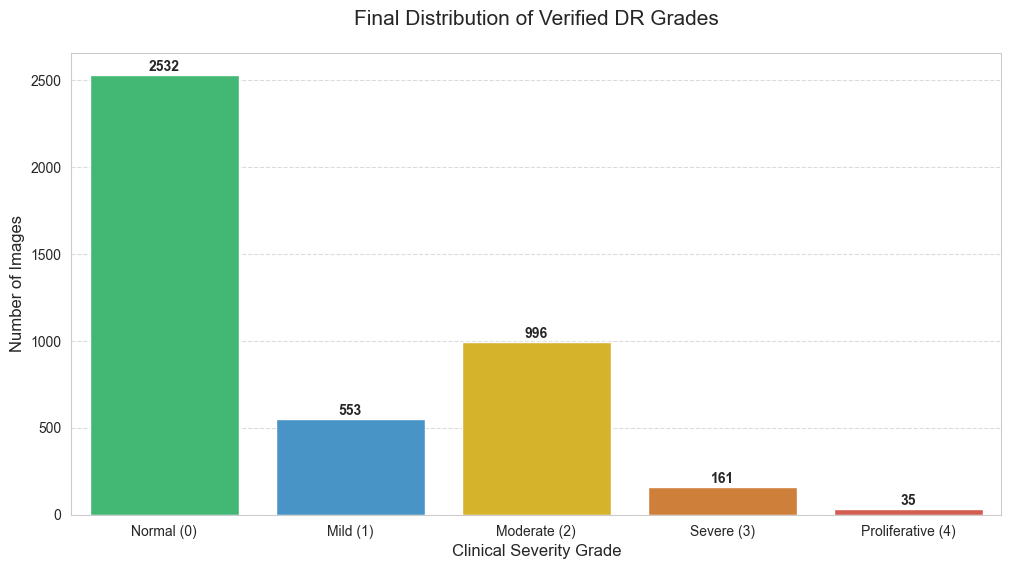

In [28]:
# 1. Calculate Final Counts and Percentages
final_counts = DR_Clean_df['Grade'].value_counts().sort_index()
final_percents = (final_counts / len(DR_Clean_df)) * 100

# Create a Summary DataFrame for display
summary_df = pd.DataFrame({
    'Grade': ['Normal (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)'],
    'Image Count': final_counts.values,
    'Percentage (%)': final_percents.values.round(2)
})

print("--- FINAL DATASET INTEGRITY SUMMARY ---")
print(summary_df.to_string(index=False))
print(f"\nTotal Cleaned Images available for Training: {len(DR_Clean_df)}")

# 2. Visualize the Class Distribution
plt.figure(figsize=(12, 6))
colors = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c'] # Medical color scale
sns.barplot(x='Grade', y='Image Count', data=summary_df, palette=colors)

plt.title('Final Distribution of Verified DR Grades', fontsize=15, pad=20)
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Clinical Severity Grade', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, count in enumerate(final_counts.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')

plt.show()

In [29]:
DR_Clean_df.to_csv('Deep Learning csv/ODIR_Cleaned_Dataset.csv', index=False)

In [30]:
DR_Clean_df.info()

<class 'pandas.DataFrame'>
Index: 4277 entries, 0 to 4535
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Patient_ID           4277 non-null   int64
 1   Image_Path           4277 non-null   str  
 2   Eye_Side             4277 non-null   str  
 3   N                    4277 non-null   int64
 4   D                    4277 non-null   int64
 5   Other_Disease        4277 non-null   int64
 6   Diagnostic_Keywords  4277 non-null   str  
 7   Patient Age          4277 non-null   int64
 8   Patient Sex          4277 non-null   str  
 9   ID                   4277 non-null   int64
 10  G                    4277 non-null   int64
 11  C                    4277 non-null   int64
 12  A                    4277 non-null   int64
 13  H                    4277 non-null   int64
 14  M                    4277 non-null   int64
 15  O                    4277 non-null   int64
 16  Condition            4277 non-null   str

In [31]:
import os
import shutil
import pandas as pd

# 1. SET YOUR PATHS
# The directory containing ALL the original images
source_dir = 'ODIR_Images/ODIR_All_Images' 

# The name of the NEW directory you want to create
destination_dir = 'ODIR_Images/ODIR_Selected_Images'

# 2. CREATE THE NEW DIRECTORY
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)
    print(f"Created directory: {destination_dir}")

# 3. GET THE LIST OF FILENAMES
# We use .unique() to ensure we don't try to copy the same file twice
image_list = DR_Clean_df['Image_Path'].unique()

print(f"Starting extraction of {len(image_list)} images...")

# 4. LOOP AND COPY
success_count = 0
error_count = 0

for filename in image_list:
    # Build the full path for source and destination
    source_path = os.path.join(source_dir, filename)
    destination_path = os.path.join(destination_dir, filename)
    
    # Check if the source file actually exists before copying
    if os.path.exists(source_path):
        try:
            # shutil.copy2 preserves original file metadata (like timestamps)
            shutil.copy2(source_path, destination_path)
            success_count += 1
        except Exception as e:
            print(f"Error copying {filename}: {e}")
            error_count += 1
    else:
        print(f"File not found: {source_path}")
        error_count += 1

# 5. FINAL REPORT
print("-" * 30)
print(f"Extraction Complete!")
print(f"Successfully copied: {success_count}")
print(f"Errors/Missing: {error_count}")

Created directory: ODIR_Images/ODIR_Selected_Images
Starting extraction of 4277 images...
------------------------------
Extraction Complete!
Successfully copied: 4277
Errors/Missing: 0
